# 1. Stage 7 overview
Optimize the saved Stage-6 shortlist with training-only cross-validation, then lock one complete configuration before the first holdout read. Macro-F1 is primary; MCC, minority metrics, probability quality, variability and country transfer provide supporting evidence. Class IDs are nominal labels and do not encode severity distance. Notebook 04 baseline fits are not repeated.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # Bound joblib workers for stable n_jobs=-1 behavior.
from IPython.display import display


In [2]:
import sys, json, time, warnings, platform
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, sklearn
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
 classification_report, confusion_matrix, f1_score, log_loss, matthews_corrcoef,
 precision_recall_curve, precision_score, recall_score, precision_recall_fscore_support)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
RANDOM_STATE=42
CLASS_ORDER=["Functional","Partially functional","Abandoned or not functional"]
CLASS_TO_ID={name:i for i,name in enumerate(CLASS_ORDER)}
ID_TO_CLASS={i:name for name,i in CLASS_TO_ID.items()}
CLASS_IDS=np.arange(3)
print({"python":platform.python_version(),"pandas":pd.__version__,"numpy":np.__version__,
 "sklearn":sklearn.__version__,"xgboost":__import__("xgboost").__version__,
 "catboost":__import__("catboost").__version__})

{'python': '3.11.9', 'pandas': '2.2.3', 'numpy': '2.3.5', 'sklearn': '1.8.0', 'xgboost': '3.2.0', 'catboost': '1.2.10'}


In [3]:
from scipy.stats import randint,loguniform,uniform
from functools import partial
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SelectKBest,mutual_info_classif
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import make_scorer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
import imblearn
ROOT=Path("..");RESULTS=ROOT/"reports/model_optimization";RESULTS.mkdir(parents=True,exist_ok=True)
print("imbalanced-learn:",imblearn.__version__)

imbalanced-learn: 0.14.2


# 2. Saved Stage-6 evidence
Load the baseline summary, 150 fold scores, class metrics, family winners, shortlist and country diagnostic. The saved shortlist must match the expected modern handoff. Search results below are exploratory; final verification uses common repeated-CV folds.

In [4]:
BASE=ROOT/"reports/model_development"
baseline=pd.read_csv(BASE/"baseline_cv_summary.csv")
baseline_folds=pd.read_csv(BASE/"baseline_cv_folds.csv")
baseline_class=pd.read_csv(BASE/"oof_class_metrics.csv")
baseline_winners=pd.read_csv(BASE/"model_family_winners.csv")
baseline_country=pd.read_csv(BASE/"country_robustness.csv")
handoff=json.loads((BASE/"notebook04_shortlist.json").read_text(encoding="utf-8"))
expected=["HistGB Base","XGBoost Base","RF Base"]
assert len(baseline)==10 and len(baseline_folds)==150 and baseline_folds.groupby("configuration").size().eq(15).all()
assert baseline_winners.configuration.head(3).tolist()==expected
assert [r["configuration"] for r in handoff["selected_baseline_variant_per_family"]]==expected
assert handoff["locked_holdout_loaded"] is False
print("Verified Stage-6 shortlist:",expected);display(baseline_winners.round(4))

Verified Stage-6 shortlist: ['HistGB Base', 'XGBoost Base', 'RF Base']


,model_family,configuration,preprocessing_variant,mean_macro_f1,sd_macro_f1,balanced_accuracy,mcc,partial_recall,partial_f1,partial_ap,train_cv_gap,log_loss,mean_fit_seconds
0,HistGradientBoosting,HistGB Base,tree_base,0.6953,0.0274,0.6720,0.6332,0.2857,0.3636,0.3855,0.3047,0.6678,1.3287
1,XGBoost,XGBoost Base,tree_base,0.6891,0.0283,0.6627,0.6285,0.2698,0.3656,0.3799,0.3109,0.5202,0.4677
2,Random Forest,RF Base,tree_base,0.6689,0.0288,0.6388,0.6128,0.2302,0.3204,0.3695,0.3307,0.6504,0.3294
3,CatBoost,CatBoost Base,catboost_native_base,0.6251,0.0326,0.6003,0.5592,0.1905,0.2652,0.3090,0.2091,0.4539,7.6584
4,Logistic Regression,LR Engineered,scaled_engineered,0.6013,0.0402,0.5756,0.5492,0.1111,0.1739,0.2751,0.0667,0.4705,0.3435


# 3. Development data and nominal target
Only the 1,434-row, 32-predictor development set enters search, resampling, feature choices and final selection. The locked holdout is first opened after a persisted selection gate near the end.

In [5]:
DATA=ROOT/"data/processed/modern"
X_train=pd.read_csv(DATA/"X_train_raw.csv")
y_text=pd.read_csv(DATA/"y_train.csv").iloc[:,0]
metadata=json.loads((DATA/"preprocessing_variants.json").read_text(encoding="utf-8"))
assert X_train.shape==(1434,32) and len(y_text)==1434
assert list(X_train.columns)==metadata["raw_predictor_columns"] and set(y_text)==set(CLASS_ORDER)
y=y_text.map(CLASS_TO_ID).astype(int)
print("Development shape:",X_train.shape,"class counts:",y_text.value_counts().to_dict())

Development shape: (1434, 32) class counts: {'Functional': 1066, 'Abandoned or not functional': 242, 'Partially functional': 126}


# 4. Reuse Notebook-03 preprocessing
The current Notebook-04 reconstruction of Notebook 03 is reproduced below. Full-development tree and native CatBoost widths are verified before fitting any classifier. OHE widths may change inside CV folds because category frequencies are learned on the training fold.

In [6]:
class FixedDataCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        cleaned = X.copy()
        cleaned["wc_savings_wp"] = cleaned["wc_savings_wp"].replace({999.0: np.nan, 888.0: np.nan})
        return cleaned

_clean_preview = FixedDataCleaner().fit_transform(X_train)
print("Training sentinel counts before:", X_train["wc_savings_wp"].isin([999, 888]).sum())
print("Training sentinel counts after:", _clean_preview["wc_savings_wp"].isin([999, 888]).sum())
assert X_train["wc_savings_wp"].equals(X_train.copy()["wc_savings_wp"])

class FeatureEngineer(BaseEstimator, TransformerMixin):
    # Adds engineered features. All fitted statistics come from the data passed
    # to .fit() only (i.e. the training split, when used inside the full pipeline).

    def fit(self, X, y=None):
        wp_age_train = X["wp_age"].astype(float)
        self.wp_age_median_ = wp_age_train.median()
        wp_age_filled = wp_age_train.fillna(self.wp_age_median_)
        q1, q2 = wp_age_filled.quantile([1 / 3, 2 / 3])
        self.wp_age_edges_ = (float(q1), float(q2))
        return self

    def transform(self, X):
        X = X.copy()

        # people_per_household: guard against division by zero / missing inputs
        qtyhh_safe = X["qtyhh_wp"].replace(0, np.nan)
        X["people_per_household"] = X["qtypeople_wp"] / qtyhh_safe

        # was_rehabilitated: clean 0/1/NaN mirror of rehabyn
        X["was_rehabilitated"] = X["rehabyn"].map({"Yes": 1, "No": 0})

        # has_management_committee: Water committee vs. everything else
        X["has_management_committee"] = (X["whomanage_wp"] == "Water committee").astype(int)

        # rehab_age: preserve structural meaning (fill 0 + explicit indicator)
        X["rehab_age_missing"] = X["rehab_age"].isna().astype(int)
        X["rehab_age"] = X["rehab_age"].fillna(0)

        # pop_1000: separate missing-indicator (kept apart from the log1p branch)
        X["pop_1000_missing"] = X["pop_1000"].isna().astype(int)

        # wp_age_group: bin using edges fitted on the training split only
        wp_age_filled = X["wp_age"].fillna(self.wp_age_median_)
        q1, q2 = self.wp_age_edges_
        X["wp_age_group"] = pd.cut(
            wp_age_filled,
            bins=[-np.inf, q1, q2, np.inf],
            labels=["New", "Established", "Old"],
        ).astype(str)

        return X


# Quick sanity preview, fit on the training split only
_fe_preview = FeatureEngineer().fit(X_train)
print(f"wp_age_group bin edges (fitted on X_train only): {_fe_preview.wp_age_edges_}")
_preview_out = _fe_preview.transform(X_train.head())
_preview_out[[
    "wp_age", "wp_age_group", "rehabyn", "was_rehabilitated",
    "whomanage_wp", "has_management_committee",
    "qtypeople_wp", "qtyhh_wp", "people_per_household",
    "rehab_age", "rehab_age_missing", "pop_1000", "pop_1000_missing",
]]

CAT_NOT_APPLICABLE_COLS = ["pumptype", "drillmethod", "piped_source", "piped_pump"]
CAT_UNKNOWN_RAW_COLS = [
    "country", "admin1", "wptype", "whomanage_wp", "rehabyn", "season",
    "cwfunded_wp", "wc_present_wp", "paytocollect_wp", "lockedfullday_wp",
]
ORDINAL_COLS = ["wc_admin_index_wp", "wc_finance_index_wp", "wc_mgmt_index_wp", "wc_maint_index_wp"]
ORDINAL_CATEGORY_ORDER = ["Inadequate", "Minimum", "Moderate", "Advanced", "Missing"]
RARE_MIN_FREQUENCY_CANDIDATES = [5, 10, 20]

def remap_ordinal_missing_code(codes):
    return np.where(codes == 4, -1, codes)

print("Structural categorical:", CAT_NOT_APPLICABLE_COLS)
print("Unknown categorical:", CAT_UNKNOWN_RAW_COLS)
print("Ordinal:", ORDINAL_COLS)

NUM_LOG_CANDIDATES = ["wp_age", "qtypeople_wp", "qtyhh_wp", "pop_1000"]
NUM_OTHER = ["elevation_wp", "latitude_wp", "longitude_wp", "rehab_age"]
NUM_WITH_INDICATOR = [
    "annual_rain", "wpqty_wp", "qtyhh_c_wp", "improved_wponly_wp",
    "wc_savings_wp", "pumpstrokes",
]
SEMANTIC_FLAGS = ["rehab_age_missing", "pop_1000_missing"]
OPTIONAL_NUM_WITH_INDICATOR = ["people_per_household", "was_rehabilitated"]
OPTIONAL_FLAGS = ["has_management_committee"]
OPTIONAL_CATEGORICAL = ["wp_age_group"]
print("Log candidates:", NUM_LOG_CANDIDATES)

RAW_PREDICTOR_COLS = (
    CAT_NOT_APPLICABLE_COLS + CAT_UNKNOWN_RAW_COLS + ORDINAL_COLS
    + NUM_LOG_CANDIDATES + NUM_OTHER + NUM_WITH_INDICATOR
)
assert len(RAW_PREDICTOR_COLS) == 32
assert len(set(RAW_PREDICTOR_COLS)) == 32
assert set(RAW_PREDICTOR_COLS) == set(X_train.columns)
print("Approved raw predictor count:", len(RAW_PREDICTOR_COLS))

class CategoricalStringifier(BaseEstimator, TransformerMixin):
    """Keep imputed nominal columns as CatBoost-safe Python strings."""

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X):
        output = X.copy()
        for column in output.columns:
            output[column] = output[column].astype(str)
        return output

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.asarray(input_features, dtype=object)


def catboost_categorical_feature_names(include_optional_engineered_features):
    """Exact transformed DataFrame names, in ColumnTransformer order."""
    unknown_cols = CAT_UNKNOWN_RAW_COLS + (OPTIONAL_CATEGORICAL if include_optional_engineered_features else [])
    return ([f"cat_not_applicable__{column}" for column in CAT_NOT_APPLICABLE_COLS]
            + [f"cat_unknown__{column}" for column in unknown_cols])


def build_catboost_native_pipeline(include_optional_engineered_features):
    """Reuse the existing tree numeric/ordinal branches; replace only nominal OHE."""
    tree_reference = build_preprocessing_pipeline(
        "tree_boosting", include_optional_engineered_features,
        rare_min_frequency=10, use_log_transform=False, scale_numeric=False,
    )
    tree_branches = tree_reference.named_steps["preprocessing"].transformers
    native_branches = []
    for name, transformer, columns in tree_branches:
        if name in {"cat_not_applicable", "cat_unknown"}:
            fill = "Not applicable" if name == "cat_not_applicable" else "Unknown"
            transformer = Pipeline([
                ("impute", SimpleImputer(strategy="constant", fill_value=fill)),
                ("to_strings", CategoricalStringifier()),
            ])
        native_branches.append((name, transformer, columns))
    preprocessor = ColumnTransformer(
        native_branches, remainder="drop", verbose_feature_names_out=True,
    )
    preprocessor.set_output(transform="pandas")
    return Pipeline([
        ("fixed_cleaning", FixedDataCleaner()),
        ("feature_engineering", FeatureEngineer()),
        ("preprocessing", preprocessor),
    ])


def build_preprocessing_pipeline(model_family, include_optional_engineered_features,
                                 rare_min_frequency=10, use_log_transform=None,
                                 scale_numeric=None):
    if model_family == "catboost_native":
        # The existing builder default is 10 for OHE families. It is ignored here;
        # explicit alternative rare thresholds are invalid for native categories.
        if rare_min_frequency not in (None, 10):
            raise ValueError("rare_min_frequency is not applicable to catboost_native")
        if use_log_transform not in (None, False) or scale_numeric not in (None, False):
            raise ValueError("CatBoost-native baseline does not use log transforms or scaling")
        return build_catboost_native_pipeline(include_optional_engineered_features)
    if model_family not in {"scale_sensitive", "tree_boosting"}:
        raise ValueError("model_family must be scale_sensitive, tree_boosting, or catboost_native")
    if not isinstance(rare_min_frequency, int) or rare_min_frequency < 1:
        raise ValueError("rare_min_frequency must be a positive integer")
    if use_log_transform is None:
        use_log_transform = model_family == "scale_sensitive"
    if scale_numeric is None:
        scale_numeric = model_family == "scale_sensitive"

    def categorical_branch(fill_value):
        return Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value=fill_value)),
            ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                      min_frequency=rare_min_frequency, sparse_output=False)),
        ])

    ordinal_branch = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("ordinal", OrdinalEncoder(categories=[ORDINAL_CATEGORY_ORDER] * len(ORDINAL_COLS))),
        ("remap_missing", FunctionTransformer(remap_ordinal_missing_code,
                                                 feature_names_out="one-to-one")),
    ])
    log_steps = [("impute", SimpleImputer(strategy="median"))]
    if use_log_transform:
        log_steps.append(("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")))
    if scale_numeric:
        log_steps.append(("scale", StandardScaler()))
    other_steps = [("impute", SimpleImputer(strategy="median"))]
    indicator_steps = [("impute", SimpleImputer(strategy="median", add_indicator=True))]
    if scale_numeric:
        other_steps.append(("scale", StandardScaler()))
        indicator_steps.append(("scale", StandardScaler()))

    unknown_cols = CAT_UNKNOWN_RAW_COLS + (OPTIONAL_CATEGORICAL if include_optional_engineered_features else [])
    indicator_cols = NUM_WITH_INDICATOR + (OPTIONAL_NUM_WITH_INDICATOR if include_optional_engineered_features else [])
    flags = SEMANTIC_FLAGS + (OPTIONAL_FLAGS if include_optional_engineered_features else [])
    preprocessor = ColumnTransformer([
        ("cat_not_applicable", categorical_branch("Not applicable"), CAT_NOT_APPLICABLE_COLS),
        ("cat_unknown", categorical_branch("Unknown"), unknown_cols),
        ("ordinal_wc_index", ordinal_branch, ORDINAL_COLS),
        ("num_skew", Pipeline(log_steps), NUM_LOG_CANDIDATES),
        ("num_other", Pipeline(other_steps), NUM_OTHER),
        ("num_indicator", Pipeline(indicator_steps), indicator_cols),
        ("semantic_flags", "passthrough", flags),
    ], remainder="drop", verbose_feature_names_out=True)
    preprocessor.set_output(transform="pandas")
    return Pipeline([
        ("fixed_cleaning", FixedDataCleaner()),
        ("feature_engineering", FeatureEngineer()),
        ("preprocessing", preprocessor),
    ])

VARIANTS = {
    "scaled_base": dict(model_family="scale_sensitive", include_optional_engineered_features=False,
                        rare_min_frequency=10, use_log_transform=True, scale_numeric=True),
    "scaled_engineered": dict(model_family="scale_sensitive", include_optional_engineered_features=True,
                              rare_min_frequency=10, use_log_transform=True, scale_numeric=True),
    "tree_base": dict(model_family="tree_boosting", include_optional_engineered_features=False,
                      rare_min_frequency=10, use_log_transform=False, scale_numeric=False),
    "tree_engineered": dict(model_family="tree_boosting", include_optional_engineered_features=True,
                            rare_min_frequency=10, use_log_transform=False, scale_numeric=False),
    "catboost_native_base": dict(model_family="catboost_native",
                                 include_optional_engineered_features=False,
                                 rare_min_frequency=None, use_log_transform=False,
                                 scale_numeric=False, one_hot_encode=False,
                                 native_categorical_handling=True,
                                 categorical_features=catboost_categorical_feature_names(False)),
    "catboost_native_engineered": dict(model_family="catboost_native",
                                       include_optional_engineered_features=True,
                                       rare_min_frequency=None, use_log_transform=False,
                                       scale_numeric=False, one_hot_encode=False,
                                       native_categorical_handling=True,
                                       categorical_features=catboost_categorical_feature_names(True)),
}
candidate_pipelines = {
    name: build_preprocessing_pipeline(**{
        key: value for key, value in config.items()
        if key not in {"one_hot_encode", "native_categorical_handling", "categorical_features"}
    })
    for name, config in VARIANTS.items()
}
print("Unfitted candidate variants:", list(candidate_pipelines))

Training sentinel counts before: 66
Training sentinel counts after: 0
wp_age_group bin edges (fitted on X_train only): (2.0, 4.0)
Structural categorical: ['pumptype', 'drillmethod', 'piped_source', 'piped_pump']
Unknown categorical: ['country', 'admin1', 'wptype', 'whomanage_wp', 'rehabyn', 'season', 'cwfunded_wp', 'wc_present_wp', 'paytocollect_wp', 'lockedfullday_wp']
Ordinal: ['wc_admin_index_wp', 'wc_finance_index_wp', 'wc_mgmt_index_wp', 'wc_maint_index_wp']
Log candidates: ['wp_age', 'qtypeople_wp', 'qtyhh_wp', 'pop_1000']
Approved raw predictor count: 32
Unfitted candidate variants: ['scaled_base', 'scaled_engineered', 'tree_base', 'tree_engineered', 'catboost_native_base', 'catboost_native_engineered']


In [7]:
tree=clone(candidate_pipelines["tree_base"]).fit_transform(X_train)
native=clone(candidate_pipelines["catboost_native_base"]).fit_transform(X_train)
cat_names=metadata["variants"]["catboost_native_base"]["categorical_features"]
assert tree.shape==(1434,102) and native.shape==(1434,40)
assert cat_names==VARIANTS["catboost_native_base"]["categorical_features"]
assert np.isfinite(tree.to_numpy(dtype=float)).all()
assert all(n in native and native[n].map(lambda v:isinstance(v,str)).all() for n in cat_names)
assert np.isfinite(native.drop(columns=cat_names).to_numpy(dtype=float)).all()
print("Preprocessing parity PASS")

Preprocessing parity PASS


# 5. Common metrics and fold-local pipelines
Search uses shuffled stratified five-fold CV. Finalist verification uses 5 by 3 repeated stratified CV. Every fold fits its complete preprocessing, optional feature selector, weighting or sampler. Macro-F1 leads; Balanced Accuracy, Macro Recall/Precision, MCC, Weighted F1, Accuracy, Log Loss, macro AP and Partial-class scores are monitored.

In [8]:
def align_probabilities(estimator,raw):
 aligned=np.zeros((len(raw),3),dtype=float)
 for j,class_id in enumerate(np.asarray(estimator.classes_,dtype=int)):
  if class_id not in CLASS_IDS:raise ValueError(f"Unexpected class ID {class_id}")
  aligned[:,class_id]=raw[:,j]
 row_sums=aligned.sum(axis=1,keepdims=True)
 if np.any(row_sums<=0):raise ValueError("A predicted probability row has no positive mass")
 aligned=aligned/row_sums
 assert aligned.shape==(len(raw),3) and np.allclose(aligned.sum(axis=1),1,atol=1e-12)
 return aligned

def calculate_metrics(truth,pred,prob):
 precision,recall,f1,_=precision_recall_fscore_support(truth,pred,labels=CLASS_IDS,zero_division=0)
 ap=np.array([average_precision_score((truth==c).astype(int),prob[:,c]) for c in CLASS_IDS])
 return {"macro_f1":f1_score(truth,pred,labels=CLASS_IDS,average="macro",zero_division=0),
  "balanced_accuracy":balanced_accuracy_score(truth,pred),
  "macro_recall":recall_score(truth,pred,labels=CLASS_IDS,average="macro",zero_division=0),
  "macro_precision":precision_score(truth,pred,labels=CLASS_IDS,average="macro",zero_division=0),
  "mcc":matthews_corrcoef(truth,pred),
  "weighted_f1":f1_score(truth,pred,labels=CLASS_IDS,average="weighted",zero_division=0),
  "accuracy":accuracy_score(truth,pred),"log_loss":log_loss(truth,prob,labels=CLASS_IDS),
  "macro_ap":float(ap.mean()),"class_precision":precision,"class_recall":recall,"class_f1":f1,"class_ap":ap}

In [9]:
search_splits=list(StratifiedKFold(5,shuffle=True,random_state=42).split(X_train,y))
repeat_splits=list(RepeatedStratifiedKFold(n_splits=5,n_repeats=3,random_state=42).split(X_train,y))
assert len(search_splits)==5 and len(repeat_splits)==15
class FoldBalancedXGB(XGBClassifier):
 def fit(self,X,y,**kwargs):
  assert "sample_weight" not in kwargs
  return super().fit(X,y,sample_weight=compute_sample_weight("balanced",y),**kwargs)
def make_pipeline(spec):
 family=spec["family"];strategy=spec.get("strategy","none");params=spec.get("params",{})
 if family=="CatBoost":pre=clone(candidate_pipelines["catboost_native_base"])
 else:pre=build_preprocessing_pipeline("tree_boosting",False,rare_min_frequency=spec.get("rare",10),
  use_log_transform=False,scale_numeric=False)
 if family=="HistGradientBoosting":
  clf=HistGradientBoostingClassifier(random_state=42,**params)
  if strategy=="weighting":clf.set_params(class_weight="balanced")
 elif family=="XGBoost":
  cls=FoldBalancedXGB if strategy=="weighting" else XGBClassifier
  clf=cls(objective="multi:softprob",eval_metric="mlogloss",random_state=42,verbosity=0,n_jobs=2,**params)
 elif family=="Random Forest":
  clf=RandomForestClassifier(random_state=42,n_jobs=2,**params)
  if strategy in ("balanced","balanced_subsample"):clf.set_params(class_weight=strategy)
 elif family=="CatBoost":
  clf=CatBoostClassifier(loss_function="MultiClass",random_seed=42,verbose=False,
   allow_writing_files=False,thread_count=2,**params)
  if strategy=="weighting":clf.set_params(auto_class_weights="Balanced")
 else:raise ValueError(family)
 steps=list(pre.steps) if strategy=="ros" else [("preprocessing",pre)]
 if spec.get("select_k"):steps.append(("selection",SelectKBest(partial(mutual_info_classif,random_state=42),k=spec["select_k"])))
 if strategy=="ros":steps.append(("sampler",RandomOverSampler(random_state=42)))
 steps.append(("classifier",clf))
 return ImbPipeline(steps) if strategy=="ros" else Pipeline(steps)
def fit_complete(pipe,spec,X,y):
 return pipe.fit(X,y,**({"classifier__cat_features":cat_names} if spec["family"]=="CatBoost" else {}))
def safe(v):
 if isinstance(v,dict):return {k:safe(x) for k,x in v.items()}
 if isinstance(v,(list,tuple)):return [safe(x) for x in v]
 if isinstance(v,np.generic):return v.item()
 return v

# 6. Fixed-budget randomized hyperparameter search
Use RandomizedSearchCV with 30 HistGB, 35 XGBoost, 30 RF and 12 CatBoost candidates, five folds each. Candidate counts were fixed before inspecting performance. MCC is saved as a secondary score; Macro-F1 controls refit. Search best scores benefit from candidate selection and are not final estimates.

In [10]:
SPACES={
"HistGradientBoosting":{"classifier__learning_rate":loguniform(.025,.2),"classifier__max_iter":randint(80,301),
 "classifier__max_leaf_nodes":randint(7,33),"classifier__max_depth":[3,4,5,6,None],
 "classifier__min_samples_leaf":randint(10,61),"classifier__l2_regularization":loguniform(.001,10)},
"XGBoost":{"classifier__n_estimators":randint(100,401),"classifier__learning_rate":loguniform(.02,.2),
 "classifier__max_depth":randint(2,7),"classifier__min_child_weight":randint(1,11),
 "classifier__subsample":uniform(.65,.35),"classifier__colsample_bytree":uniform(.65,.35),
 "classifier__gamma":uniform(0,3),"classifier__reg_alpha":loguniform(.001,3),
 "classifier__reg_lambda":loguniform(.3,10)},
"Random Forest":{"classifier__n_estimators":randint(100,401),"classifier__max_depth":[5,8,12,16,None],
 "classifier__max_features":["sqrt",.5,.8],"classifier__min_samples_split":randint(2,21),
 "classifier__min_samples_leaf":randint(1,11),"classifier__bootstrap":[True,False]},
"CatBoost":{"classifier__iterations":randint(150,451),"classifier__depth":randint(3,8),
 "classifier__learning_rate":loguniform(.025,.18),"classifier__l2_leaf_reg":loguniform(1,15),
 "classifier__random_strength":uniform(0,2),"classifier__bagging_temperature":uniform(0,1)}}
BUDGET={"HistGradientBoosting":30,"XGBoost":35,"Random Forest":30,"CatBoost":12}
FILES={"HistGradientBoosting":"histgb_search_results.csv","XGBoost":"xgboost_search_results.csv",
 "Random Forest":"rf_search_results.csv","CatBoost":"catboost_challenger_results.csv"}
searches={}
for family,n in BUDGET.items():
 print("Searching",family,n,flush=True);start=time.perf_counter()
 search=RandomizedSearchCV(make_pipeline({"family":family}),SPACES[family],n_iter=n,
  scoring={"f1_macro":"f1_macro","mcc":make_scorer(matthews_corrcoef)},refit="f1_macro",
  cv=search_splits,random_state=42,n_jobs=2,pre_dispatch=2,error_score="raise",return_train_score=True)
 search.fit(X_train,y,**({"classifier__cat_features":cat_names} if family=="CatBoost" else {}))
 table=pd.DataFrame(search.cv_results_);table.to_csv(RESULTS/FILES[family],index=False)
 b=search.best_index_
 searches[family]={"params":{k.removeprefix("classifier__"):v for k,v in search.best_params_.items()},
  "score":float(search.best_score_),"mcc":float(table.loc[b,"mean_test_mcc"]),
  "train_macro_f1":float(table.loc[b,"mean_train_f1_macro"]),
  "n_iter":n,"fits":n*5,"elapsed_seconds":time.perf_counter()-start}
 print(family,"search Macro-F1",round(search.best_score_,4),flush=True)
(RESULTS/"search_best_parameters.json").write_text(json.dumps(safe(searches),indent=2)+"\n",encoding="utf-8")
display(pd.DataFrame([{"family":f,**{k:v for k,v in s.items() if k!="params"}} for f,s in searches.items()]).round(4))

Searching HistGradientBoosting 30
HistGradientBoosting search Macro-F1 0.6945
Searching XGBoost 35
XGBoost search Macro-F1 0.692
Searching Random Forest 30
Random Forest search Macro-F1 0.6975
Searching CatBoost 12
CatBoost search Macro-F1 0.6494


,family,score,mcc,train_macro_f1,n_iter,fits,elapsed_seconds
0,HistGradientBoosting,0.6945,0.6424,0.9794,30,150,141.1320
1,XGBoost,0.6920,0.6270,0.9955,35,175,60.4043
2,Random Forest,0.6975,0.6204,0.8667,30,150,109.9460
3,CatBoost,0.6494,0.5832,0.8929,12,60,965.1958


# 7. Baseline versus exploratory search
Load baseline values from Stage-6 files and compare with the search scores, including MCC and train-to-CV gap. Repeated-CV finalist verification later gives the principal tuned estimate.

In [11]:
BASE_NAMES={"HistGradientBoosting":"HistGB Base","XGBoost":"XGBoost Base",
 "Random Forest":"RF Base","CatBoost":"CatBoost Base"}
rows=[]
for family,s in searches.items():
 b=baseline.set_index("configuration").loc[BASE_NAMES[family]]
 rows.append({"family":family,"baseline_macro_f1":b.mean_macro_f1,"search_macro_f1":s["score"],
  "difference":s["score"]-b.mean_macro_f1,"baseline_mcc":b.mean_mcc,"search_mcc":s["mcc"],
  "baseline_train_cv_gap":b.mean_train_cv_gap,"search_train_cv_gap":s["train_macro_f1"]-s["score"]})
search_compare=pd.DataFrame(rows);search_compare.to_csv(RESULTS/"baseline_vs_search.csv",index=False)
display(search_compare.round(4))

,family,baseline_macro_f1,search_macro_f1,difference,baseline_mcc,search_mcc,baseline_train_cv_gap,search_train_cv_gap
0,HistGradientBoosting,0.6953,0.6945,-0.0008,0.6332,0.6424,0.3047,0.2849
1,XGBoost,0.6891,0.6920,0.0030,0.6285,0.6270,0.3109,0.3035
2,Random Forest,0.6689,0.6975,0.0286,0.6128,0.6204,0.3307,0.1692
3,CatBoost,0.6251,0.6494,0.0242,0.5592,0.5832,0.2091,0.2435


# 8. Fold-local imbalance strategies
After tuning, compare none, class or sample weighting and RandomOverSampler on identical five-fold splits; RF also tests balanced subsampling. XGBoost derives weights only from the labels supplied to each fit. ROS runs inside imbalanced-learn Pipeline after numeric OHE. SMOTENC is deferred for a technical reason: authoritative tree preprocessing already one-hot encodes nominal categories, while valid SMOTENC requires a new category-aware intermediate representation and post-sampler encoder. Standard SMOTE after OHE can synthesize invalid fractional indicators.

In [12]:
def scores(truth,pred,prob):
 v=calculate_metrics(truth,pred,prob)
 out={k:float(x) for k,x in v.items() if np.isscalar(x)}
 out.update(partial_precision=float(v["class_precision"][1]),partial_recall=float(v["class_recall"][1]),
            partial_f1=float(v["class_f1"][1]),partial_ap=float(v["class_ap"][1]))
 return out
def oof(spec):
 pred=np.full(len(y),-1,int);prob=np.full((len(y),3),np.nan);seen=np.zeros(len(y),int);train=[]
 for tr,va in search_splits:
  pipe=make_pipeline(spec);fit_complete(pipe,spec,X_train.iloc[tr],y.iloc[tr])
  pred[va]=pipe.predict(X_train.iloc[va]).astype(int).reshape(-1)
  prob[va]=align_probabilities(pipe.named_steps["classifier"],pipe.predict_proba(X_train.iloc[va]))
  seen[va]+=1
  train.append(f1_score(y.iloc[tr],pipe.predict(X_train.iloc[tr]).astype(int).reshape(-1),average="macro"))
 assert (seen==1).all() and np.isfinite(prob).all()
 return scores(y.to_numpy(),pred,prob),pred,prob,float(np.mean(train))
PRIMARY=["HistGradientBoosting","XGBoost","Random Forest"];imb=[]
for family in PRIMARY:
 methods=["none","weighting","ros"] if family!="Random Forest" else ["none","balanced","balanced_subsample","ros"]
 for strategy in methods:
  print("Imbalance",family,strategy,flush=True)
  spec={"family":family,"params":searches[family]["params"],"strategy":strategy}
  v,_,_,tr=oof(spec)
  imb.append({"family":family,"strategy":strategy,**v,"train_macro_f1":tr,"train_cv_gap":tr-v["macro_f1"]})
imbalance=pd.DataFrame(imb);imbalance.to_csv(RESULTS/"imbalance_comparison.csv",index=False)
display(imbalance[["family","strategy","macro_f1","mcc","partial_precision","partial_recall","partial_f1","partial_ap"]].round(4))
best_imb=(imbalance.sort_values(["macro_f1","balanced_accuracy","partial_f1"],ascending=False)
 .groupby("family",sort=False).head(1).set_index("family"))
print("Chosen training-only strategies:",best_imb.strategy.to_dict())

Imbalance HistGradientBoosting none
Imbalance HistGradientBoosting weighting
Imbalance HistGradientBoosting ros
Imbalance XGBoost none
Imbalance XGBoost weighting
Imbalance XGBoost ros
Imbalance Random Forest none
Imbalance Random Forest balanced
Imbalance Random Forest balanced_subsample
Imbalance Random Forest ros


,family,strategy,macro_f1,mcc,partial_precision,partial_recall,partial_f1,partial_ap
0,HistGradientBoosting,none,0.6945,0.6413,0.6731,0.2778,0.3933,0.4033
1,HistGradientBoosting,weighting,0.6683,0.5841,0.3643,0.3730,0.3686,0.3660
2,HistGradientBoosting,ros,0.6897,0.6152,0.4433,0.3413,0.3857,0.3690
3,XGBoost,none,0.6918,0.6258,0.5417,0.3095,0.3939,0.4075
4,XGBoost,weighting,0.6801,0.5923,0.4032,0.3968,0.4000,0.3779
5,XGBoost,ros,0.6869,0.6096,0.4182,0.3651,0.3898,0.3783
6,Random Forest,none,0.6985,0.6200,0.6562,0.3333,0.4421,0.4280
7,Random Forest,balanced,0.6873,0.5921,0.3913,0.5000,0.4390,0.4173
8,Random Forest,balanced_subsample,0.6873,0.5921,0.3913,0.5000,0.4390,0.4173
9,Random Forest,ros,0.6953,0.6096,0.4219,0.4286,0.4252,0.4230


Chosen training-only strategies: {'Random Forest': 'none', 'HistGradientBoosting': 'none', 'XGBoost': 'none'}


# 9. Small preprocessing and feature-selection experiment
Notebook 04 already found base features stronger for the primary families. On the strongest tuned family, compare OHE rare thresholds 5, 10 and 20, then fold-local mutual-information selection of 60 or 80 features. Adopt only a Macro-F1 gain above 0.005. Optional coordinate removal is deferred under the fixed budget; country robustness is retained.

In [13]:
lead=max(PRIMARY,key=lambda f:best_imb.loc[f,"macro_f1"])
strategy=best_imb.loc[lead,"strategy"];pre=[]
for rare in [5,10,20]:
 v,_,_,_=oof({"family":lead,"params":searches[lead]["params"],"strategy":strategy,"rare":rare})
 pre.append({"experiment":"rare_threshold","value":rare,**v})
for k in [60,80]:
 v,_,_,_=oof({"family":lead,"params":searches[lead]["params"],"strategy":strategy,"select_k":k})
 pre.append({"experiment":"select_k","value":k,**v})
preprocessing=pd.DataFrame(pre);preprocessing.to_csv(RESULTS/"preprocessing_experiments.csv",index=False)
display(preprocessing[["experiment","value","macro_f1","mcc","partial_f1"]].round(4))
reference=float(preprocessing.query("experiment=='rare_threshold' and value==10").macro_f1.iloc[0])
winner=preprocessing.sort_values("macro_f1",ascending=False).iloc[0];lead_change={}
if winner.macro_f1>reference+.005:
 lead_change={("rare" if winner.experiment=="rare_threshold" else "select_k"):int(winner.value)}
print("Accepted preprocessing change:",lead_change or "none")

,experiment,value,macro_f1,mcc,partial_f1
0,rare_threshold,5,0.6908,0.6133,0.4211
1,rare_threshold,10,0.6985,0.6200,0.4421
2,rare_threshold,20,0.6963,0.6176,0.4352
3,select_k,60,0.7099,0.6473,0.4330
4,select_k,80,0.6920,0.6151,0.4188


Accepted preprocessing change: {'select_k': 60}


# 10. Targeted CatBoost challenger
CatBoost uses its exact native categorical feature names and only 12 random search candidates. Compare its tuned fit without weighting against fold-local automatic class weighting. It enters repeated-CV finalist validation only if its search Macro-F1 lies within 0.03 of the weakest primary search result. This predeclared budget rule does not pick the final model.

In [14]:
cat_rows=[]
for strategy in ["none","weighting"]:
 print("CatBoost challenger",strategy,flush=True)
 v,_,_,_=oof({"family":"CatBoost","params":searches["CatBoost"]["params"],"strategy":strategy})
 cat_rows.append({"strategy":strategy,**v})
cat_compare=pd.DataFrame(cat_rows);cat_compare.to_csv(RESULTS/"catboost_strategy_comparison.csv",index=False)
display(cat_compare[["strategy","macro_f1","mcc","partial_recall","partial_f1","partial_ap"]].round(4))
cat_competitive=searches["CatBoost"]["score"]>=min(searches[f]["score"] for f in PRIMARY)-.03
print("CatBoost enters finalist set:",cat_competitive)

CatBoost challenger none
CatBoost challenger weighting


,strategy,macro_f1,mcc,partial_recall,partial_f1,partial_ap
0,none,0.6488,0.5815,0.2222,0.3077,0.3476
1,weighting,0.6623,0.5563,0.3889,0.3920,0.3735


CatBoost enters finalist set: False


# 11. Complete finalists and common repeated 5 by 3 CV
Each primary family contributes its tuned configuration with its best training-only imbalance strategy. The lead may carry an accepted preprocessing change. CatBoost joins only under its prior rule. Every full pipeline receives identical 15-fold repeated splits; train-to-CV gaps supplement the primary Macro-F1 estimate.

In [15]:
finalists=[]
for family in PRIMARY:
 spec={"family":family,"params":searches[family]["params"],"strategy":str(best_imb.loc[family,"strategy"])}
 if family==lead:spec.update(lead_change)
 spec["name"]=family+" / "+spec["strategy"]+(f" / {lead_change}" if family==lead and lead_change else "")
 finalists.append(spec)
if cat_competitive:
 cs=cat_compare.sort_values("macro_f1",ascending=False).iloc[0]
 finalists.append({"family":"CatBoost","params":searches["CatBoost"]["params"],
  "strategy":cs.strategy,"name":"CatBoost / "+cs.strategy})
assert 3<=len(finalists)<=4
print("Finalists:",[s["name"] for s in finalists])
folds=[]
for spec in finalists:
 print("Repeated CV",spec["name"],flush=True)
 for n,(tr,va) in enumerate(repeat_splits,1):
  pipe=make_pipeline(spec);start=time.perf_counter();fit_complete(pipe,spec,X_train.iloc[tr],y.iloc[tr])
  elapsed=time.perf_counter()-start
  trainpred=pipe.predict(X_train.iloc[tr]).astype(int).reshape(-1)
  pred=pipe.predict(X_train.iloc[va]).astype(int).reshape(-1)
  prob=align_probabilities(pipe.named_steps["classifier"],pipe.predict_proba(X_train.iloc[va]))
  v=scores(y.iloc[va].to_numpy(),pred,prob)
  trainf=f1_score(y.iloc[tr],trainpred,labels=CLASS_IDS,average="macro",zero_division=0)
  folds.append({"finalist":spec["name"],"family":spec["family"],"repeat":(n-1)//5+1,
   "fold":(n-1)%5+1,"fit_seconds":elapsed,"train_macro_f1":trainf,
   "train_cv_gap":trainf-v["macro_f1"],**v})
finalist_folds=pd.DataFrame(folds);finalist_folds.to_csv(RESULTS/"finalist_cv_folds.csv",index=False)
cols=["macro_f1","balanced_accuracy","macro_recall","macro_precision","mcc","weighted_f1","accuracy",
 "log_loss","macro_ap","partial_precision","partial_recall","partial_f1","partial_ap",
 "train_macro_f1","train_cv_gap"]
summary=[]
for spec in finalists:
 block=finalist_folds[finalist_folds.finalist==spec["name"]]
 row={"finalist":spec["name"],"family":spec["family"],"strategy":spec["strategy"]}
 for col in cols:row[col]=block[col].mean()
 row["sd_macro_f1"]=block.macro_f1.std(ddof=1);summary.append(row)
finalist_summary=pd.DataFrame(summary).sort_values("macro_f1",ascending=False).reset_index(drop=True)
finalist_summary.to_csv(RESULTS/"finalist_cv_summary.csv",index=False)
display(finalist_summary.round(4))

Finalists: ['HistGradientBoosting / none', 'XGBoost / none', "Random Forest / none / {'select_k': 60}"]
Repeated CV HistGradientBoosting / none
Repeated CV XGBoost / none
Repeated CV Random Forest / none / {'select_k': 60}


,finalist,family,strategy,macro_f1,balanced_accuracy,macro_recall,macro_precision,mcc,weighted_f1,accuracy,log_loss,macro_ap,partial_precision,partial_recall,partial_f1,partial_ap,train_macro_f1,train_cv_gap,sd_macro_f1
0,Random Forest / none / {'select_k': 60},Random Forest,none,0.6996,0.6691,0.6691,0.7756,0.6349,0.8472,0.8594,0.4578,0.7548,0.6523,0.3205,0.4220,0.4484,0.8647,0.1652,0.0481
1,XGBoost / none,XGBoost,none,0.6874,0.6594,0.6594,0.7537,0.6264,0.8437,0.8561,0.4462,0.7457,0.5800,0.2912,0.3821,0.4264,0.9949,0.3075,0.0291
2,HistGradientBoosting / none,HistGradientBoosting,none,0.6793,0.6497,0.6497,0.7577,0.6216,0.8410,0.8550,0.4685,0.7326,0.6038,0.2697,0.3677,0.4137,0.9806,0.3013,0.0221


# 12. One OOF prediction per development row
The fixed stratified five-fold pass produces one class and aligned probability vector per development row for each finalist. Per-class Precision, Recall, F1 and Average Precision expose minority trade-offs. Raw confusion matrices retain the nominal class order.

In [16]:
class_rows=[];oof_rows=[];confusions={}
for spec in finalists:
 print("Finalist OOF",spec["name"],flush=True)
 _,pred,prob,_=oof(spec);confusions[spec["name"]]=confusion_matrix(y,pred,labels=CLASS_IDS)
 p,r,f,s=precision_recall_fscore_support(y,pred,labels=CLASS_IDS,zero_division=0)
 for k,label in enumerate(CLASS_ORDER):
  class_rows.append({"finalist":spec["name"],"class":label,"support":int(s[k]),
   "precision":p[k],"recall":r[k],"f1":f[k],
   "average_precision":average_precision_score((y.to_numpy()==k).astype(int),prob[:,k])})
 for i in range(len(y)):
  oof_rows.append({"finalist":spec["name"],"row_index":i,"truth":int(y.iloc[i]),
   "prediction":int(pred[i]),**{f"probability_{k}":float(prob[i,k]) for k in CLASS_IDS}})
class_results=pd.DataFrame(class_rows);oof_results=pd.DataFrame(oof_rows)
assert oof_results.groupby("finalist").size().eq(1434).all()
class_results.to_csv(RESULTS/"finalist_oof_class_metrics.csv",index=False)
oof_results.to_csv(RESULTS/"finalist_oof_predictions.csv",index=False)
display(class_results.round(4))
normalized_confusions={name:cm/np.maximum(cm.sum(axis=1,keepdims=True),1) for name,cm in confusions.items()}
confusion_rows=[]
for name,cm in confusions.items():
 for actual in CLASS_IDS:
  for predicted in CLASS_IDS:
   confusion_rows.append({"finalist":name,"actual":CLASS_ORDER[actual],"predicted":CLASS_ORDER[predicted],
    "count":int(cm[actual,predicted]),"row_normalized":float(normalized_confusions[name][actual,predicted])})
finalist_confusion=pd.DataFrame(confusion_rows)
finalist_confusion.to_csv(RESULTS/"finalist_confusion_matrices.csv",index=False)
display(finalist_confusion.round(4))


Finalist OOF HistGradientBoosting / none
Finalist OOF XGBoost / none
Finalist OOF Random Forest / none / {'select_k': 60}


,finalist,class,support,precision,recall,f1,average_precision
0,HistGradientBoosting / none,Functional,1066,0.8835,0.9606,0.9204,0.9522
1,HistGradientBoosting / none,Partially functional,126,0.6731,0.2778,0.3933,0.4033
2,HistGradientBoosting / none,Abandoned or not functional,242,0.8027,0.7397,0.7699,0.8366
3,XGBoost / none,Functional,1066,0.8882,0.9465,0.9164,0.9523
4,XGBoost / none,Partially functional,126,0.5417,0.3095,0.3939,0.4075
5,XGBoost / none,Abandoned or not functional,242,0.7920,0.7397,0.7650,0.8621
6,Random Forest / none / {'select_k': 60},Functional,1066,0.8911,0.9522,0.9206,0.9537
7,Random Forest / none / {'select_k': 60},Partially functional,126,0.6176,0.3333,0.4330,0.4245
8,Random Forest / none / {'select_k': 60},Abandoned or not functional,242,0.8018,0.7521,0.7761,0.8545


,finalist,actual,predicted,count,row_normalized
0,HistGradientBoosting / none,Functional,Functional,1024,0.9606
1,HistGradientBoosting / none,Functional,Partially functional,12,0.0113
2,HistGradientBoosting / none,Functional,Abandoned or not functional,30,0.0281
3,HistGradientBoosting / none,Partially functional,Functional,77,0.6111
4,HistGradientBoosting / none,Partially functional,Partially functional,35,0.2778
5,HistGradientBoosting / none,Partially functional,Abandoned or not functional,14,0.1111
6,HistGradientBoosting / none,Abandoned or not functional,Functional,58,0.2397
7,HistGradientBoosting / none,Abandoned or not functional,Partially functional,5,0.0207
8,HistGradientBoosting / none,Abandoned or not functional,Abandoned or not functional,179,0.7397
9,XGBoost / none,Functional,Functional,1009,0.9465


# 13. Saved baselines against optimized finalists
Compare every tuned primary family against the matching saved Stage-6 baseline: Macro-F1, MCC, Partial Recall/F1 and train-to-CV gap. This descriptive comparison reuses development data and does not refit the baseline models.

In [17]:
compare=[]
for _,r in finalist_summary.iterrows():
 b=baseline.set_index("configuration").loc[BASE_NAMES[r.family]]
 bc=baseline_class[(baseline_class.configuration==BASE_NAMES[r.family])&
  (baseline_class["class"]=="Partially functional")].iloc[0]
 oc=class_results[(class_results.finalist==r.finalist)&
  (class_results["class"]=="Partially functional")].iloc[0]
 compare.append({"family":r.family,"finalist":r.finalist,"baseline_macro_f1":b.mean_macro_f1,
  "optimized_macro_f1":r.macro_f1,"macro_f1_change":r.macro_f1-b.mean_macro_f1,
  "baseline_mcc":b.mean_mcc,"optimized_mcc":r.mcc,
  "baseline_partial_recall":bc.recall,"optimized_partial_recall":oc.recall,
  "baseline_partial_f1":bc.f1,"optimized_partial_f1":oc.f1,
  "baseline_train_cv_gap":b.mean_train_cv_gap,"optimized_train_cv_gap":r.train_cv_gap})
baseline_vs_optimized=pd.DataFrame(compare)
baseline_vs_optimized.to_csv(RESULTS/"baseline_vs_optimized.csv",index=False)
display(baseline_vs_optimized.round(4))

,family,finalist,baseline_macro_f1,optimized_macro_f1,macro_f1_change,baseline_mcc,optimized_mcc,baseline_partial_recall,optimized_partial_recall,baseline_partial_f1,optimized_partial_f1,baseline_train_cv_gap,optimized_train_cv_gap
0,Random Forest,Random Forest / none / {'select_k': 60},0.6689,0.6996,0.0306,0.6128,0.6349,0.2302,0.3333,0.3204,0.4330,0.3307,0.1652
1,XGBoost,XGBoost / none,0.6891,0.6874,-0.0017,0.6285,0.6264,0.2698,0.3095,0.3656,0.3939,0.3109,0.3075
2,HistGradientBoosting,HistGradientBoosting / none,0.6953,0.6793,-0.0160,0.6332,0.6216,0.2857,0.2778,0.3636,0.3933,0.3047,0.3013


# 14. Secondary country robustness
The two leading repeated-CV finalists face Leave-One-Country-Out evaluation with their full optimized pipelines. Country Macro-F1 uses observed classes because some countries lack a class. Supports, Balanced Accuracy, MCC and Accuracy are reported. This diagnostic does not override the primary ranking.

In [18]:
countries=[];groups=X_train.country.astype(str).to_numpy();logo=LeaveOneGroupOut()
for spec in [s for s in finalists if s["name"] in finalist_summary.finalist.head(2).tolist()]:
 for tr,va in logo.split(X_train,y,groups):
  pipe=make_pipeline(spec);fit_complete(pipe,spec,X_train.iloc[tr],y.iloc[tr])
  truth=y.iloc[va].to_numpy();pred=pipe.predict(X_train.iloc[va]).astype(int).reshape(-1)
  observed=np.unique(truth)
  countries.append({"finalist":spec["name"],"held_out_country":groups[va[0]],"rows":len(va),
   "observed_classes":", ".join(CLASS_ORDER[int(k)] for k in observed),
   "macro_f1_observed_classes":f1_score(truth,pred,labels=observed,average="macro",zero_division=0),
   "balanced_accuracy":balanced_accuracy_score(truth,pred),"mcc":matthews_corrcoef(truth,pred),
   "accuracy":accuracy_score(truth,pred),
   **{f"support_{CLASS_ORDER[k]}":int((truth==k).sum()) for k in CLASS_IDS}})
country=pd.DataFrame(countries);country.to_csv(RESULTS/"finalist_country_robustness.csv",index=False)
display(country.round(4))

,finalist,held_out_country,rows,observed_classes,macro_f1_observed_classes,balanced_accuracy,mcc,accuracy,support_Functional,support_Partially functional,support_Abandoned or not functional
0,XGBoost / none,Ethiopia,307,"Functional, Partially functional, Abandoned or...",0.4116,0.4276,0.3580,0.6840,184,26,97
1,XGBoost / none,India,105,"Functional, Partially functional, Abandoned or...",0.6578,0.6667,0.7883,0.9524,91,5,9
2,XGBoost / none,Malawi,215,"Functional, Partially functional, Abandoned or...",0.4306,0.4410,0.1914,0.8093,175,26,14
3,XGBoost / none,Mali,126,"Functional, Partially functional, Abandoned or...",0.5441,0.5275,0.5836,0.9365,114,2,10
4,XGBoost / none,Mozambique,93,"Functional, Partially functional, Abandoned or...",0.4868,0.4886,0.1947,0.9247,88,3,2
5,XGBoost / none,Nepal,267,"Functional, Partially functional, Abandoned or...",0.3588,0.4104,0.0837,0.3596,165,45,57
6,XGBoost / none,Niger,113,"Functional, Partially functional, Abandoned or...",0.4953,0.4782,0.4929,0.8230,84,5,24
7,XGBoost / none,Rwanda,103,"Functional, Partially functional, Abandoned or...",0.3851,0.4067,0.0925,0.4660,67,11,25
8,XGBoost / none,Uganda,105,"Functional, Partially functional, Abandoned or...",0.6616,0.6667,0.7495,0.9714,98,3,4
9,Random Forest / none / {'select_k': 60},Ethiopia,307,"Functional, Partially functional, Abandoned or...",0.5877,0.6109,0.7086,0.8502,184,26,97


# 15. Final selection rule, defined before holdout
Highest mean repeated-CV Macro-F1 wins. Candidates within 0.005 of the top form a practical tie. Resolve it by higher Balanced Accuracy, higher Partial OOF F1, higher Partial OOF Recall, higher MCC, lower Macro-F1 SD, then lower Log Loss. Do not sort Macro-F1 again within the tie. No composite score is used. Country results remain secondary context.

In [19]:
ranked=finalist_summary.sort_values("macro_f1",ascending=False)
tied=ranked[ranked.macro_f1>=float(ranked.iloc[0].macro_f1)-.005].copy()
partial_class_rows=class_results[class_results["class"]=="Partially functional"].set_index("finalist")
tied["oof_partial_f1"]=tied.finalist.map(partial_class_rows.f1)
tied["oof_partial_recall"]=tied.finalist.map(partial_class_rows.recall)
chosen=tied.sort_values(["balanced_accuracy","oof_partial_f1","oof_partial_recall",
 "mcc","sd_macro_f1","log_loss"],ascending=[False,False,False,False,True,True]).iloc[0]
selected=next(s for s in finalists if s["name"]==chosen.finalist)
print("Practical-tie candidates:",tied.finalist.tolist(),"selected:",chosen.finalist)

Practical-tie candidates: ["Random Forest / none / {'select_k': 60}"] selected: Random Forest / none / {'select_k': 60}


# 16. Persist the final complete configuration
The model family, Notebook-03 preprocessing variant, tuned parameters, imbalance method, feature choices, class mapping, selection rule and development CV evidence are saved before any holdout input call. This configuration cannot be revised after holdout evaluation.

In [20]:
FINAL_SELECTION=safe({"finalist":selected["name"],"model_family":selected["family"],
 "preprocessing_variant":"catboost_native_base" if selected["family"]=="CatBoost" else "tree_base",
 "hyperparameters":selected["params"],"imbalance_strategy":selected["strategy"],
 "rare_min_frequency":selected.get("rare",10) if selected["family"]!="CatBoost" else None,
 "feature_selection_k":selected.get("select_k"),"feature_set":"base","class_mapping":CLASS_TO_ID,
 "primary_cv_macro_f1":chosen.macro_f1,"cv_sd":chosen.sd_macro_f1,
 "balanced_accuracy":chosen.balanced_accuracy,"mcc":chosen.mcc,
 "partial_f1":chosen.oof_partial_f1,"partial_recall":chosen.oof_partial_recall,
 "selection_rule":"Repeated-CV Macro-F1; within 0.005: Balanced Accuracy, Partial F1, Partial Recall, MCC, lower SD, lower Log Loss",
 "development_rows":len(X_train),"holdout_evaluated":False})
LOCK=RESULTS/"final_selection_locked.json"
LOCK.write_text(json.dumps(FINAL_SELECTION,indent=2)+"\n",encoding="utf-8")
assert json.loads(LOCK.read_text(encoding="utf-8"))==FINAL_SELECTION
print("FINAL CONFIGURATION LOCKED BEFORE HOLDOUT: YES");display(FINAL_SELECTION)

FINAL CONFIGURATION LOCKED BEFORE HOLDOUT: YES


{'finalist': "Random Forest / none / {'select_k': 60}",
 'model_family': 'Random Forest',
 'preprocessing_variant': 'tree_base',
 'hyperparameters': {'bootstrap': False,
  'max_depth': None,
  'max_features': 0.5,
  'min_samples_leaf': 5,
  'min_samples_split': 8,
  'n_estimators': 336},
 'imbalance_strategy': 'none',
 'rare_min_frequency': 10,
 'feature_selection_k': 60,
 'feature_set': 'base',
 'class_mapping': {'Functional': 0,
  'Partially functional': 1,
  'Abandoned or not functional': 2},
 'primary_cv_macro_f1': 0.6995798685801132,
 'cv_sd': 0.04812455152560639,
 'balanced_accuracy': 0.6690930039286535,
 'mcc': 0.6349234570476817,
 'partial_f1': 0.4329896907216495,
 'partial_recall': 0.3333333333333333,
 'selection_rule': 'Repeated-CV Macro-F1; within 0.005: Balanced Accuracy, Partial F1, Partial Recall, MCC, lower SD, lower Log Loss',
 'development_rows': 1434,
 'holdout_evaluated': False}

# 17. Holdout gate and historical context
An older project workflow previously inspected this same holdout. No redesigned Notebook-04/05 choice above used those historical outcomes. Notebook 04 never loaded it; Notebook 05 has persisted its final selection. The next cell is this notebook's first holdout read and verifies the lock before opening either holdout file.

In [21]:
assert LOCK.exists() and json.loads(LOCK.read_text(encoding="utf-8"))==FINAL_SELECTION
assert FINAL_SELECTION["holdout_evaluated"] is False and len(finalist_folds)==15*len(finalists)
assert chosen.finalist==FINAL_SELECTION["finalist"]
X_holdout=pd.read_csv(DATA/"X_test_raw.csv")
y_holdout_text=pd.read_csv(DATA/"y_test.csv").iloc[:,0]
assert X_holdout.shape==(359,32) and list(X_holdout.columns)==list(X_train.columns)
assert len(y_holdout_text)==359 and set(y_holdout_text)<=set(CLASS_ORDER)
y_holdout=y_holdout_text.map(CLASS_TO_ID).astype(int)
print("Holdout opened after lock:",X_holdout.shape)

Holdout opened after lock: (359, 32)


# 18. One-time final holdout assessment
Fit the exact locked pipeline once on all 1,434 development rows and predict the 359-row holdout. Report the same overall and class metrics, plus raw and normalized confusion matrices. This assessment does not trigger retuning.

In [22]:
final_pipe=make_pipeline(selected);fit_complete(final_pipe,selected,X_train,y)
hold_pred=final_pipe.predict(X_holdout).astype(int).reshape(-1)
hold_prob=align_probabilities(final_pipe.named_steps["classifier"],final_pipe.predict_proba(X_holdout))
hold_scores=scores(y_holdout.to_numpy(),hold_pred,hold_prob)
p,r,f,s=precision_recall_fscore_support(y_holdout,hold_pred,labels=CLASS_IDS,zero_division=0)
hold_class=pd.DataFrame([{"class":label,"support":int(s[k]),"precision":p[k],"recall":r[k],
 "f1":f[k],"average_precision":average_precision_score((y_holdout.to_numpy()==k).astype(int),hold_prob[:,k])}
 for k,label in enumerate(CLASS_ORDER)])
hold_cm=confusion_matrix(y_holdout,hold_pred,labels=CLASS_IDS)
hold_norm=hold_cm/np.maximum(hold_cm.sum(axis=1,keepdims=True),1)
(RESULTS/"final_holdout_metrics.json").write_text(json.dumps(safe(hold_scores),indent=2)+"\n",encoding="utf-8")
hold_class.to_csv(RESULTS/"final_holdout_class_metrics.csv",index=False)
print("Holdout metrics:",{k:round(float(v),4) for k,v in hold_scores.items()})
display(hold_class.round(4));print("Raw confusion matrix:\n",hold_cm)
print("Normalized confusion matrix:\n",np.round(hold_norm,4))

Holdout metrics: {'macro_f1': 0.6699, 'balanced_accuracy': 0.6392, 'macro_recall': 0.6392, 'macro_precision': 0.7897, 'mcc': 0.6466, 'weighted_f1': 0.8462, 'accuracy': 0.8663, 'log_loss': 0.3353, 'macro_ap': 0.793, 'partial_precision': 0.6667, 'partial_recall': 0.1935, 'partial_f1': 0.3, 'partial_ap': 0.5208}


,class,support,precision,recall,f1,average_precision
0,Functional,267,0.8810,0.9700,0.9234,0.9742
1,Partially functional,31,0.6667,0.1935,0.3000,0.5208
2,Abandoned or not functional,61,0.8214,0.7541,0.7863,0.8840


Raw confusion matrix:
 [[259   1   7]
 [ 22   6   3]
 [ 13   2  46]]
Normalized confusion matrix:
 [[0.97   0.0037 0.0262]
 [0.7097 0.1935 0.0968]
 [0.2131 0.0328 0.7541]]


# 19. CV versus holdout
Compare selected repeated-CV means with the single fixed holdout score. Differences describe uncertainty, not a reason to revise the lock. Historical holdout exposure limits claims that this split was untouched across all project history.

In [23]:
cv_holdout=pd.DataFrame([{"metric":k,"repeated_cv":float(chosen[k]),"holdout":float(hold_scores[k]),
 "holdout_minus_cv":float(hold_scores[k]-chosen[k])}
 for k in ["macro_f1","balanced_accuracy","mcc","accuracy","log_loss",
           "partial_recall","partial_f1","partial_ap"]])
cv_holdout.to_csv(RESULTS/"cv_vs_holdout.csv",index=False);display(cv_holdout.round(4))

,metric,repeated_cv,holdout,holdout_minus_cv
0,macro_f1,0.6996,0.6699,-0.0297
1,balanced_accuracy,0.6691,0.6392,-0.0299
2,mcc,0.6349,0.6466,0.0116
3,accuracy,0.8594,0.8663,0.0069
4,log_loss,0.4578,0.3353,-0.1225
5,partial_recall,0.3205,0.1935,-0.1270
6,partial_f1,0.4220,0.3000,-0.1220
7,partial_ap,0.4484,0.5208,0.0724


# 20. Interpretation, plots and deployment handoff
Charts condense the numerical tables. Calculated outputs determine which tune helped, what imbalance did to Partial precision/recall, how finalists differed in MCC and stability, whether country transfer was weak, and whether holdout agreed with CV. A later export stage must move any notebook-local estimator code into importable modules before serialization. This notebook saves the lock, exact preprocessing and parameters, class mapping, CV and holdout evidence; it does not change the backend.

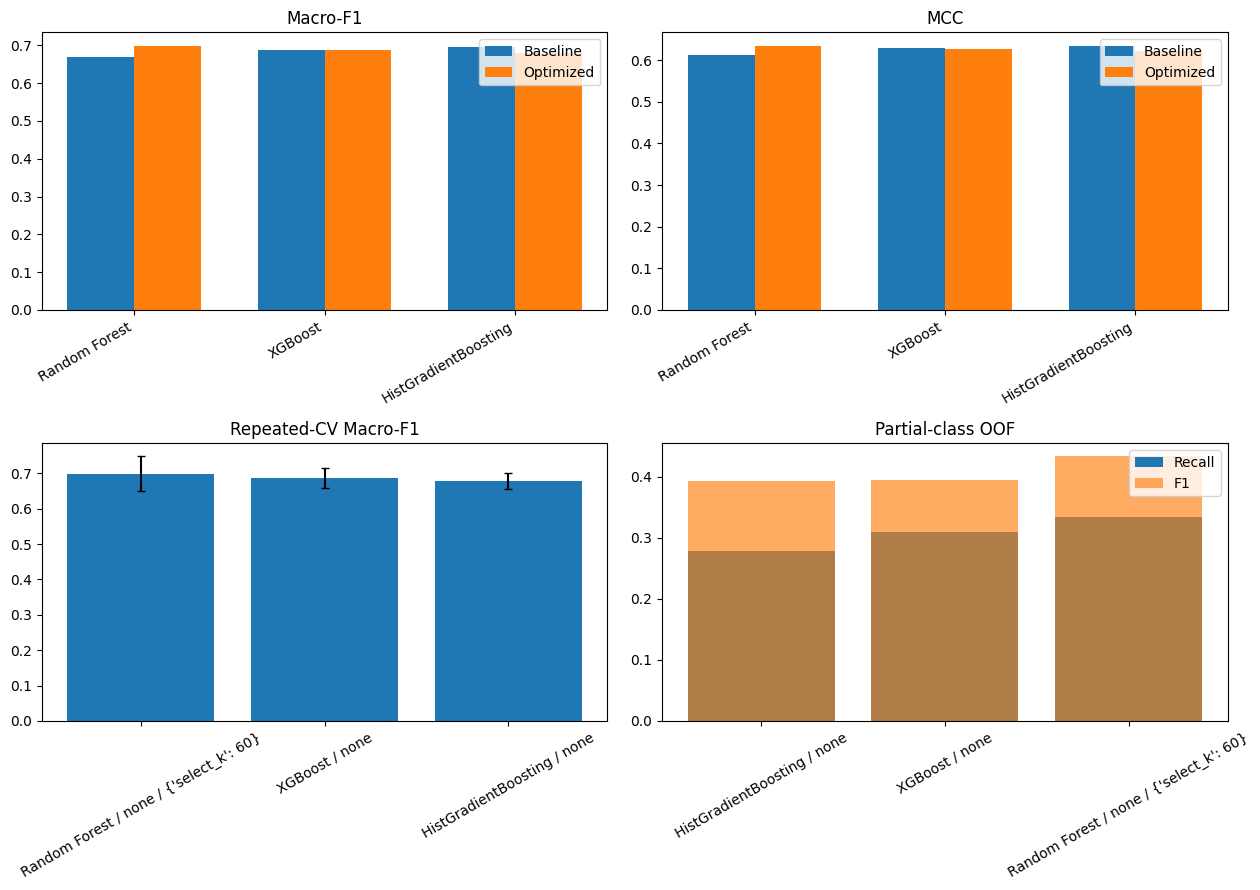

Largest tuned gain: {'family': 'Random Forest', 'macro_f1_change': 0.0306335969120185}
Strongest finalist MCC: {'finalist': "Random Forest / none / {'select_k': 60}", 'mcc': 0.6349234570476817}
Strongest Partial F1: {'finalist': "Random Forest / none / {'select_k': 60}", 'f1': 0.4329896907216495}
Country means: {"Random Forest / none / {'select_k': 60}": 0.4902, 'XGBoost / none': 0.4924}
Selected: Random Forest / none / {'select_k': 60} holdout minus CV Macro-F1: -0.0297
HistGradientBoosting weighting: Macro-F1 -0.0262; Partial recall +0.0952; Partial precision -0.3087
HistGradientBoosting ros: Macro-F1 -0.0049; Partial recall +0.0635; Partial precision -0.2298
XGBoost weighting: Macro-F1 -0.0117; Partial recall +0.0873; Partial precision -0.1384
XGBoost ros: Macro-F1 -0.0049; Partial recall +0.0556; Partial precision -0.1235
Random Forest balanced: Macro-F1 -0.0111; Partial recall +0.1667; Partial precision -0.2649
Random Forest balanced_subsample: Macro-F1 -0.0111; Partial recall +0.

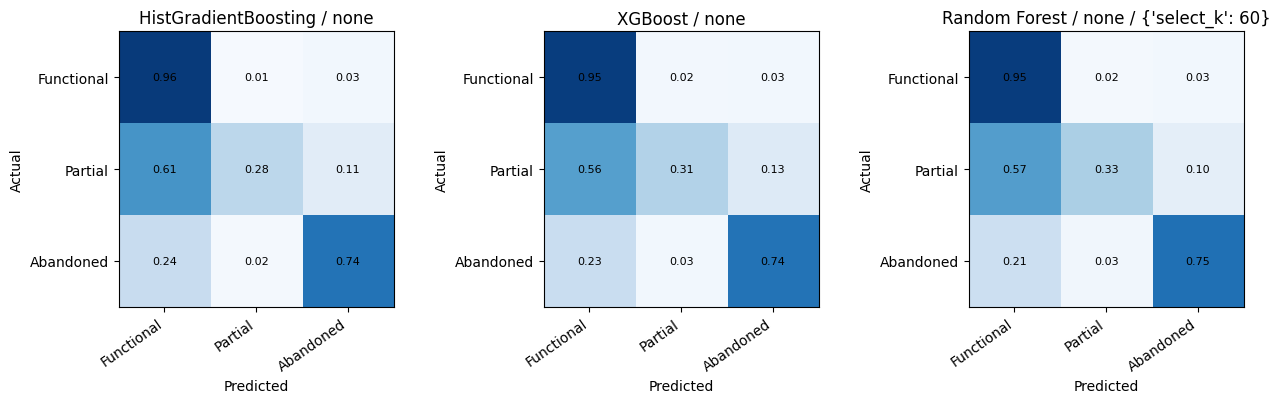

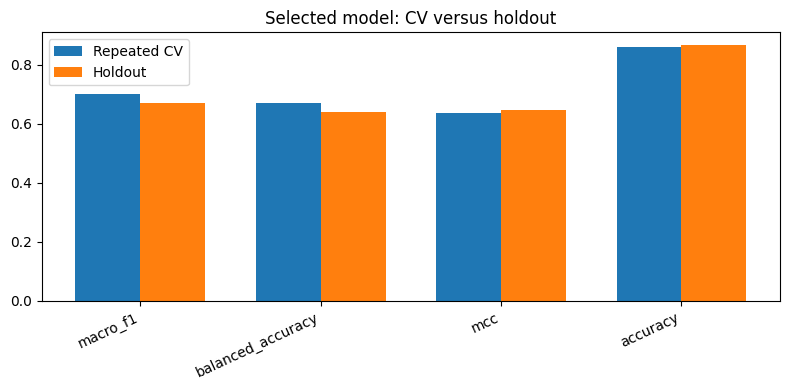

In [24]:
fig,ax=plt.subplots(2,2,figsize=(13,9));x=np.arange(len(baseline_vs_optimized));w=.35
for j,(b,o,title) in enumerate([("baseline_macro_f1","optimized_macro_f1","Macro-F1"),
 ("baseline_mcc","optimized_mcc","MCC")]):
 a=ax[0,j];a.bar(x-w/2,baseline_vs_optimized[b],w,label="Baseline")
 a.bar(x+w/2,baseline_vs_optimized[o],w,label="Optimized")
 a.set_xticks(x,baseline_vs_optimized.family,rotation=30,ha="right");a.set_title(title);a.legend()
ax[1,0].bar(finalist_summary.finalist,finalist_summary.macro_f1,
 yerr=finalist_summary.sd_macro_f1,capsize=3)
ax[1,0].tick_params(axis="x",rotation=30);ax[1,0].set_title("Repeated-CV Macro-F1")
part=class_results[class_results["class"]=="Partially functional"]
ax[1,1].bar(part.finalist,part.recall,label="Recall")
ax[1,1].bar(part.finalist,part.f1,alpha=.65,label="F1")
ax[1,1].tick_params(axis="x",rotation=30);ax[1,1].set_title("Partial-class OOF");ax[1,1].legend()
fig.tight_layout();plt.show()
print("Largest tuned gain:",baseline_vs_optimized.loc[baseline_vs_optimized.macro_f1_change.idxmax(),["family","macro_f1_change"]].to_dict())
print("Strongest finalist MCC:",finalist_summary.loc[finalist_summary.mcc.idxmax(),["finalist","mcc"]].to_dict())
print("Strongest Partial F1:",part.loc[part.f1.idxmax(),["finalist","f1"]].to_dict())
print("Country means:",country.groupby("finalist").macro_f1_observed_classes.mean().round(4).to_dict())
print("Selected:",FINAL_SELECTION["finalist"],"holdout minus CV Macro-F1:",round(float(hold_scores["macro_f1"]-chosen.macro_f1),4))

for family in PRIMARY:
 block=imbalance[imbalance.family==family].set_index("strategy")
 base=block.loc["none"]
 for method in [m for m in block.index if m!="none"]:
  row=block.loc[method]
  print(f"{family} {method}: Macro-F1 {row.macro_f1-base.macro_f1:+.4f}; Partial recall {row.partial_recall-base.partial_recall:+.4f}; Partial precision {row.partial_precision-base.partial_precision:+.4f}")
print("CatBoost search competitive for finalist validation:",cat_competitive)
print("Rare threshold scores:",preprocessing.query("experiment=='rare_threshold'").set_index("value").macro_f1.round(4).to_dict())
print("Most stable finalist:",finalist_summary.loc[finalist_summary.sd_macro_f1.idxmin(),"finalist"])
print("Final choice led repeated-CV Macro-F1 and MCC among finalists; no holdout score changed it.")
fig,axes=plt.subplots(1,len(normalized_confusions),figsize=(4.3*len(normalized_confusions),4))
for ax,(name,cm) in zip(np.atleast_1d(axes),normalized_confusions.items()):
 ax.imshow(cm,cmap="Blues",vmin=0,vmax=1)
 for (row,col),value in np.ndenumerate(cm):ax.text(col,row,f"{value:.2f}",ha="center",va="center",fontsize=8)
 ax.set_xticks(range(3),["Functional","Partial","Abandoned"],rotation=35,ha="right")
 ax.set_yticks(range(3),["Functional","Partial","Abandoned"])
 ax.set_title(name);ax.set_xlabel("Predicted");ax.set_ylabel("Actual")
fig.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(8,4))
comparison=cv_holdout[cv_holdout.metric.isin(["macro_f1","balanced_accuracy","mcc","accuracy"])]
x=np.arange(len(comparison));ax.bar(x-.18,comparison.repeated_cv,.36,label="Repeated CV")
ax.bar(x+.18,comparison.holdout,.36,label="Holdout")
ax.set_xticks(x,comparison.metric,rotation=25,ha="right");ax.legend();ax.set_title("Selected model: CV versus holdout")
fig.tight_layout();plt.show()


In [25]:
optimization_summary=safe({"stage7_status":"PASS","stage6_baselines_rerun":False,
 "search_budget":BUDGET,"search_results":searches,"selected_finalist":FINAL_SELECTION,
 "finalist_summary":finalist_summary.to_dict(orient="records"),"holdout_metrics":hold_scores,
 "post_holdout_tuning":False,
 "smotenc_status":"Deferred: tree preprocessing one-hot encodes nominal fields; valid SMOTENC needs a mixed representation and post-sampler encoder.",
 "geography_ablation_status":"Deferred under fixed budget; country diagnostic retained."})
(RESULTS/"optimization_summary.json").write_text(json.dumps(optimization_summary,indent=2)+"\n",encoding="utf-8")
assert len(baseline_folds)==150 and len(finalist_folds)==15*len(finalists)
assert oof_results.groupby("finalist").size().eq(1434).all()
assert LOCK.exists() and (RESULTS/"final_holdout_metrics.json").exists()
print("Stage 7 complete; one holdout evaluation followed the lock.")

Stage 7 complete; one holdout evaluation followed the lock.
